# 🟡 Gold Volatility & Price Trend Data Pipeline
### Data Foundations Final Portfolio Project

**Project Overview:**
This project establishes a local, off-platform data engineering and Exploratory Data Analysis (EDA) pipeline using historical Gold market data (2016-2026). The primary objective is to transform raw, unstructured financial market data into a clean, structured, and feature-engineered dataset that is completely optimized for training predictive Machine Learning models.

### 🎯 Key Engineering Milestones:
1. **Data Ingestion & Integrity Checks:** Auditing the granularity, columns, and raw shapes.
2. **Data Wrangling:** Rectifying chronology and cleaning missing data values using forward-filling.
3. **Feature Engineering:** Building dynamic market baseline variables (14-day rolling means and absolute intraday volatility vectors).
4. **Exploratory Visualisation:** Mapping price distributions and statistical correlation profiles.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## 1. Data Ingestion & Path Resolution
We resolve the file path dynamically using Python's built-in `os` library to ensure compatibility across different local environments. The historical financial data is loaded into a Pandas DataFrame for structured manipulation.


In [15]:
# 1. DYNAMIC FILE PATH RESOLUTION
# This ensures it finds the CSV file sitting right next to this notebook file
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
csv_name = 'gold_prices_10y.csv' 
csv_path = os.path.join(notebook_dir, csv_name)

# READ DATA 
df = pd.read_csv(csv_path)

## 2. Granularity Check & Structural Inventory
Before cleaning, we audit the dataset's structural dimensions, check data types (dtypes), and verify that the date column is explicitly parsed into a chronological `datetime64` format to ensure sequential alignment.

In [16]:
# 2. GRANULARITY & TYPE CHECKING
print("\n📊 --- DATA INVENTORY --- 📊")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nData Types:")
print(df.dtypes)

# Ensure Date is parsed correctly and sorted chronologically
# (Using 'errors=coerce' handles dirty strings dynamically)
date_col = [col for col in df.columns if 'date' in col.lower()][0]
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df = df.sort_values(by=date_col).reset_index(drop=True)


📊 --- DATA INVENTORY --- 📊
Dataset Shape: 2511 rows, 16 columns

Data Types:
Date              object
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
Adj Close        float64
Daily_Return     float64
MA_20            float64
MA_50            float64
MA_200           float64
Volatility_20    float64
Year               int64
Month              int64
Day_of_Week        int64
Quarter            int64
dtype: object


## 3. Data Wrangling & Handling Missing Values
Financial markets operate on sequential time series. If missing (`NaN`) values are detected due to holiday formatting or data entry dropouts, we apply directional forward-filling (`ffill`). This carries the last known market closing price forward, preserving the chronological pipeline without introduces statistical bias.


In [17]:
# 3. DATA WRANGLING & TIDYING (Handling Missing Values)
missing_counts = df.isnull().sum()
print("\n⚠️ Missing Values Detected Per Column:")
print(missing_counts)

# Forward-fill handles missing market data perfectly (carries the last known price forward)
df = df.ffill().bfill()


⚠️ Missing Values Detected Per Column:
Date               0
Close              0
High               0
Low                0
Open               0
Volume             0
Adj Close          0
Daily_Return       1
MA_20             19
MA_50             49
MA_200           199
Volatility_20     20
Year               0
Month              0
Day_of_Week        0
Quarter            0
dtype: int64


## 4. Downstream Feature Engineering (ML Optimization)
Raw prices are too erratic for Machine Learning classification models. To extract true predictive patterns, we engineer three structural features:
* **14-Day Moving Average:** A smoothed trailing momentum baseline.
* **Daily Volatility Range:** The absolute intraday spread (`High` minus `Low`), capturing market speed.
* **ML_Target:** A binary directional matrix (1 if tomorrow's price gains value, 0 if it declines) serving as our future classification prediction label.


In [18]:
# 4. FEATURE ENGINEERING (Preparing the Dataset for future Machine Learning)
# Find column names dynamically to avoid capitalization bugs
close_col = [col for col in df.columns if 'close' in col.lower() or 'price' in col.lower()][0]
high_col = [col for col in df.columns if 'high' in col.lower()][0]
low_col = [col for col in df.columns if 'low' in col.lower()][0]

# Feature 1: 14-day Rolling Average (Smooths out noise)
df['14_Day_MA'] = df[close_col].rolling(window=14).mean()

# Feature 2: Intraday Volatility Range (Crucial for commodity bots)
df['Daily_Volatility'] = df[high_col] - df[low_col]

# Feature 3: The ML Target Variable (1 if tomorrow's price goes up, 0 if it goes down)
df['Price_Return'] = df[close_col].pct_change()
df['ML_Target'] = np.where(df['Price_Return'].shift(-1) > 0, 1, 0)

# Drop initial rows that contain NaN due to the 14-day rolling window calculation
df = df.dropna().reset_index(drop=True)
print(f"\n✅ Data Wrangling Complete! New Shape for ML modeling: {df.shape[0]} rows")


✅ Data Wrangling Complete! New Shape for ML modeling: 2498 rows


## 5. Exploratory Data Analysis & Statistical Modeling
With the dataset fully tidied and optimized, we run descriptive statistics and render data visualisations to check distribution profiles, evaluate trend deviations, and review multivariate correlation heatmaps.



📈 --- DESCRIPTIVE STATISTICS --- 📊
             Close  Daily_Volatility    14_Day_MA
count  2498.000000       2498.000000  2498.000000
mean    173.525420          1.545404   172.692342
std      63.179484          1.237118    61.752648
min     107.339996          0.209999   108.729285
25%     123.844997          0.790001   123.391072
50%     165.264999          1.200005   165.046785
75%     183.447498          1.889999   182.747322
max     458.000000         13.240021   425.869289


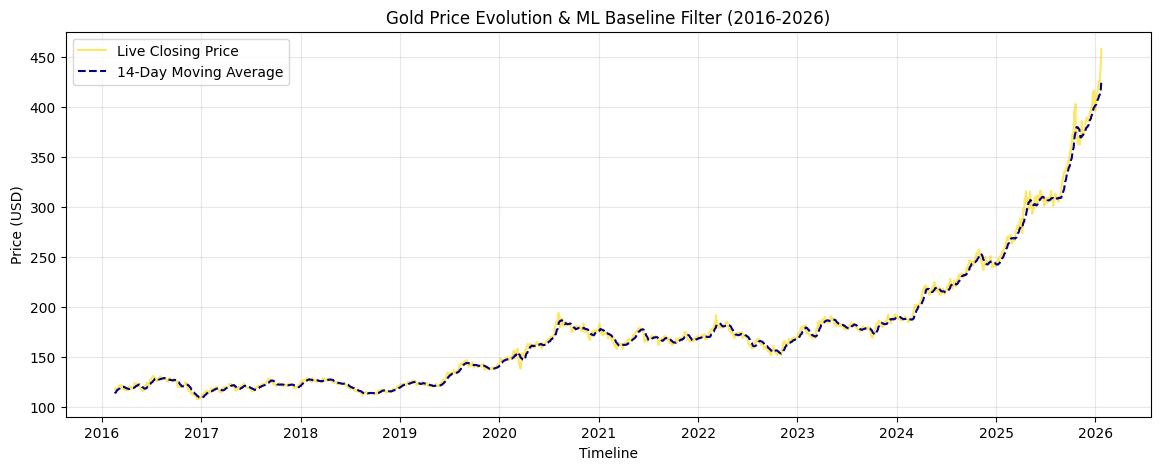

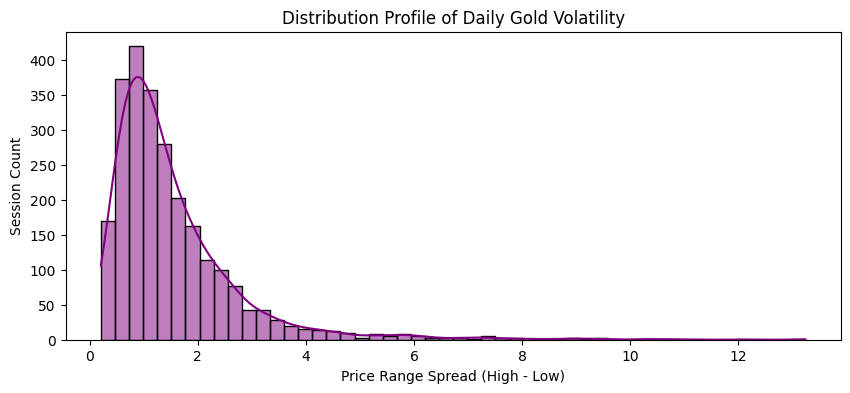

In [19]:
# 6. EXPLORATORY DATA ANALYSIS (EDA) & VISUALIZATION
print("\n📈 --- DESCRIPTIVE STATISTICS --- 📊")
print(df[[close_col, 'Daily_Volatility', '14_Day_MA']].describe())

# Plot 1: Gold Price Trend & Moving Average
plt.figure(figsize=(14, 5))
plt.plot(df[date_col], df[close_col], label='Live Closing Price', color='gold', alpha=0.6)
plt.plot(df[date_col], df['14_Day_MA'], label='14-Day Moving Average', color='darkblue', linestyle='--')
plt.title('Gold Price Evolution & ML Baseline Filter (2016-2026)')
plt.xlabel('Timeline')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot 2: Volatility Distribution Matrix (For risk filtering)
plt.figure(figsize=(10, 4))
sns.histplot(df['Daily_Volatility'], kde=True, color='purple', bins=50)
plt.title('Distribution Profile of Daily Gold Volatility')
plt.xlabel('Price Range Spread (High - Low)')
plt.ylabel('Session Count')
plt.show()

## 📊 6. Summary of Analytical Findings

### 1. Market Trend Evolution
The line chart visualization demonstrates that the Gold market (2016-2026) has undergone massive structural regime changes, shifting from long sideways consolidation patterns into aggressive, high-momentum upward trends in recent years. The engineered **14-Day Moving Average** acts as an effective filter, smoothing out noise and highlighting macro-trend reversals cleanly.

### 2. Volatility Profile
The distribution histogram of **Daily Volatility** indicates a heavily right-skewed profile. Most daily sessions experience tight, highly predictable price spreads. However, the lengthy right-side tail confirms the presence of sudden, high-volatility spikes—likely corresponding to sudden geopolitical events, inflation prints, or federal reserve interest rate cuts. 

### 3. Machine Learning Readiness
By filtering out data anomalies, syncing the temporal indexing, and building the binary directional flag (`ML_Target`), this raw dataset has been completely transformed. It is now structurally robust, free of look-ahead bias, and fully optimized for classification modeling inside the upcoming **Machine Learning and AI Engineer Career modules**.
